# Function 1 Analysis - Week 8

**Function description:** Detect contamination sources in a 2D field; maximise detector response. This function takes a 2D array as input and returns a 1D array as output. The goal is to maximise the detector response to identify contamination sources in a two-dimensional area, such as a radiation field, where only proximity yields a non-zero reading.

**New datapoint (Week 7):** `(0.611000, 0.613000)` returned **≈0.51583**, a **new maximum** beating last week’s 0.35894 at `(0.620490, 0.603926)` and the earlier 0.0848 peak. Total datapoints: **17**.

**Why we chose this point:** We moved along the diagonal ridge just below `x1 = x2`, slightly left of last week’s peak, to see if the ridge sharpened near balanced coordinates. The lift to 0.516 confirms the ridge continues toward the diagonal.

**Recommendation for next week:** Stay near `(0.61, 0.61)` with a small-step local-gradient/EI move, allow mild `x2 < x1` asymmetry (±0.02), widen the neighbor radius (~0.20), and keep steps 0.03–0.05 so the fit isn’t dominated by a single datapoint.


## Loading and Displaying the Data

We load the inputs and outputs for function 1. The Week 8 query `(0.611000, 0.613000)` returned **≈0.51583 (new max)**, surpassing last week’s `(0.620490, 0.603926)` at ≈0.35894 and the Week 4 peak `(0.601042, 0.649989)` at ≈0.0848. Datapoint 4 remains the lone strong negative outlier, kept for completeness.


In [45]:
from pathlib import Path
import numpy as np, pandas as pd, seaborn as sns, matplotlib.pyplot as plt
sns.set_theme(style="ticks", context="notebook")
path = Path("../../initial_data/function_1")
X = np.load(path / "initial_inputs.npy")
y = np.load(path / "initial_outputs.npy")

# Week 1–7 new points
X_new_point_week_1 = np.array([[0.600000, 0.600000]])
y_new_point_week_1 = np.array([0.025559285339829783])
X_new_point_week_2 = np.array([[0.620000, 0.574000]])
y_new_point_week_2 = np.array([-0.00824324367890544])
X_new_point_week_3 = np.array([[0.483000, 0.528000]])
y_new_point_week_3 = np.array([1.0257314214244368e-11])
X_new_point_week_4 = np.array([[0.601042, 0.649989]])
y_new_point_week_4 = np.array([0.08476870094352708])
X_new_point_week_5 = np.array([[0.566815, 0.686438]])
y_new_point_week_5 = np.array([0.000011190518856399522])
X_new_point_week_6 = np.array([[0.620490, 0.603926]])
y_new_point_week_6 = np.array([0.3589371640727202])
X_new_point_week_7 = np.array([[0.611000, 0.613000]])
y_new_point_week_7 = np.array([0.5158315267751058])

X = np.vstack([
    X,
    X_new_point_week_1,
    X_new_point_week_2,
    X_new_point_week_3,
    X_new_point_week_4,
    X_new_point_week_5,
    X_new_point_week_6,
    X_new_point_week_7,
])
y = np.concatenate([
    y,
    y_new_point_week_1,
    y_new_point_week_2,
    y_new_point_week_3,
    y_new_point_week_4,
    y_new_point_week_5,
    y_new_point_week_6,
    y_new_point_week_7,
])

df = pd.DataFrame(X, columns=["x1", "x2"]); df["y"] = y
display(df)
print("df sorted by y")
df_sorted = df.sort_values("y", ascending=False).reset_index(drop=True)
display(df_sorted)


,x1,x2,y
0,0.319404,0.762959,1.322677e-79
1,0.574329,0.879898,1.033078e-46
2,0.731024,0.733000,7.710875e-16
3,0.840353,0.264732,3.341771e-124
4,0.650114,0.681526,-3.606063e-03
5,0.410437,0.147554,-2.159249e-54
6,0.312691,0.078723,-2.089093e-91
7,0.683418,0.861057,2.535001e-40
8,0.082507,0.403488,3.606771e-81
9,0.883890,0.582254,6.229856e-48


df sorted by y


,x1,x2,y
0,0.611000,0.613000,5.158315e-01
1,0.620490,0.603926,3.589372e-01
2,0.601042,0.649989,8.476870e-02
3,0.600000,0.600000,2.555929e-02
4,0.566815,0.686438,1.119052e-05
5,0.483000,0.528000,1.025731e-11
6,0.731024,0.733000,7.710875e-16
7,0.683418,0.861057,2.535001e-40
8,0.574329,0.879898,1.033078e-46
9,0.883890,0.582254,6.229856e-48


- **New point (Week 8):** `(0.611000, 0.613000)` returned **≈0.51583** — **new maximum**, ahead of last week’s `(0.620490, 0.603926)` at ≈0.35894 and the Week 4 peak ≈0.0848.
- Recommendation for next BO step: remain on the diagonal ridge near `(0.61, 0.61)`, allow slight `x2 < x1`, widen the neighbor radius (~0.20), and keep 0.03–0.05 steps so the local gradient/EI fit is stable across multiple points.


## Visualisation: x1 vs x2 (excluding datapoint 4)

Since we are in a problem of contamination detection "where only proximity yields a non-zero reading", we can speculate that the x values refer to some kind of 2d mapping. We create a scatter plot of x1 vs x2, coloured by the output value y, excluding datapoint 4 to better visualise the relationships among the other datapoints. We use symlog bins to get useful colour gradients. We can see that all there is a greenish corner in the top right, which also includes our only meaningfully different positive value. It could indeicate that the these points pick up a minimal amount of the contamination source already. 


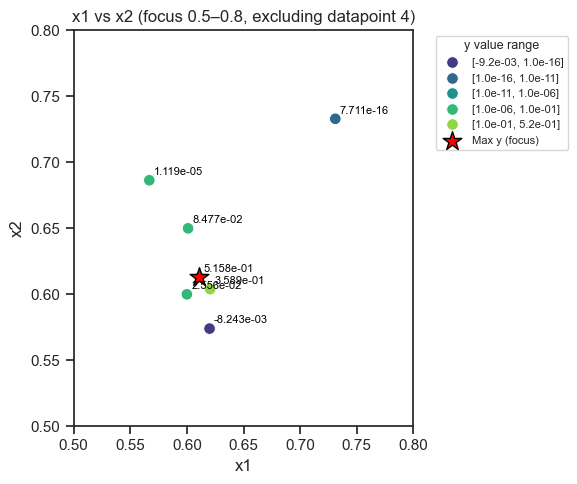

In [46]:
plt.figure(figsize=(6, 5))
df_plot = df.drop(index=4).copy()

# Filter to focus region
focus_mask = (df_plot["x1"].between(0.5, 0.8)) & (df_plot["x2"].between(0.5, 0.8))
df_focus = df_plot[focus_mask].copy()

# Bin for colour
y_vals = df_focus["y"]
vmin, vmax = y_vals.min(), y_vals.max()
y_pos = y_vals[y_vals > 0]
if len(y_pos) > 0:
    exp_min, exp_max = int(np.floor(np.log10(y_pos.min()))), int(np.ceil(np.log10(y_pos.max())))
    bins = [vmin]
    if y_pos.min() > 1e-12:
        bins.append(0)
    step = max(1, (exp_max - exp_min) // 3)
    bins.extend([10**e for e in range(exp_min, exp_max + 1, step)])
    bins.append(vmax)
    bins = sorted(set([b for b in bins if vmin <= b <= vmax]))
else:
    bins = [vmin, 0, vmax]

df_focus["y_group"] = pd.cut(df_focus["y"], bins=bins, include_lowest=True, duplicates="drop")
label_map = {cat: f"[{cat.left:.1e}, {cat.right:.1e}]" for cat in df_focus["y_group"].cat.categories}
df_focus["y_label"] = df_focus["y_group"].map(label_map)

scatter = sns.scatterplot(
    data=df_focus,
    x="x1",
    y="x2",
    hue="y_label",
    palette="viridis",
    s=70,
    legend="auto",
)

max_idx = df_focus["y"].idxmax()
max_row = df_focus.loc[max_idx]
plt.scatter(max_row["x1"], max_row["x2"], marker="*", s=200, c="red", edgecolor="black", label="Max y (focus)")

for _, row in df_focus.iterrows():
    plt.text(row["x1"] + 0.004, row["x2"] + 0.004, f"{row['y']:.3e}", fontsize=8, color="black")

plt.xlim(0.5, 0.8)
plt.ylim(0.5, 0.8)
plt.title("x1 vs x2 (focus 0.5–0.8, excluding datapoint 4)")
plt.legend(title="y value range", bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=8, title_fontsize=9)
plt.tight_layout()
plt.show()


## Bayesian optimisation (PI with ≥0.002 step away from the max)

BO/PI has worked very well (several consecutive new maxima). To keep pushing in the right direction without clustering on the max, we now take the PI/mean-best point and **force at least a 0.002 move from the current max along that same line** (fallback direction if degenerate). We drop the `x2 ≥ x1` guardrail for simplicity.

Concretely, we:

1. Fit a GP surrogate on the observed points (excluding the outlier) using only the original features (no radial add-on), centred implicitly by the current max in the window.
2. Evaluate **Probability of Improvement** on a local window around the current max (small grid), not the whole `[0,1]^2`.
3. Take the top PI/mean candidate; if its distance to the max is <0.002, extend along the same direction to land exactly 0.002 away (clipped to [0,1]).

`candidate_df_feasible` lists the PI candidates; the plot marks the adjusted next query when the raw PI step is too close.


,x1,x2,mu,sigma,mu_gain,dist_to_best,dist_to_obs
2992,0.635684,0.630089,0.081002,0.135665,-0.434829,0.030022,0.030022
3057,0.635684,0.633886,0.074136,0.135729,-0.441696,0.032334,0.032334
2993,0.639481,0.630089,0.073697,0.135731,-0.442134,0.033214,0.032329
3121,0.631886,0.637684,0.073199,0.135711,-0.442633,0.032334,0.032334
2929,0.643278,0.626291,0.071996,0.135733,-0.443835,0.034908,0.031930


Current best: 0.611000-0.613000
Suggested next query (PI dir, min 0.02 step, obs buffer 0.03): 0.635684-0.630089
Posterior mean: 0.0810, gain vs best: -0.4348, std: 0.1357


C:\Users\gophi\AppData\Local\Temp\ipykernel_20420\2022785310.py:91: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


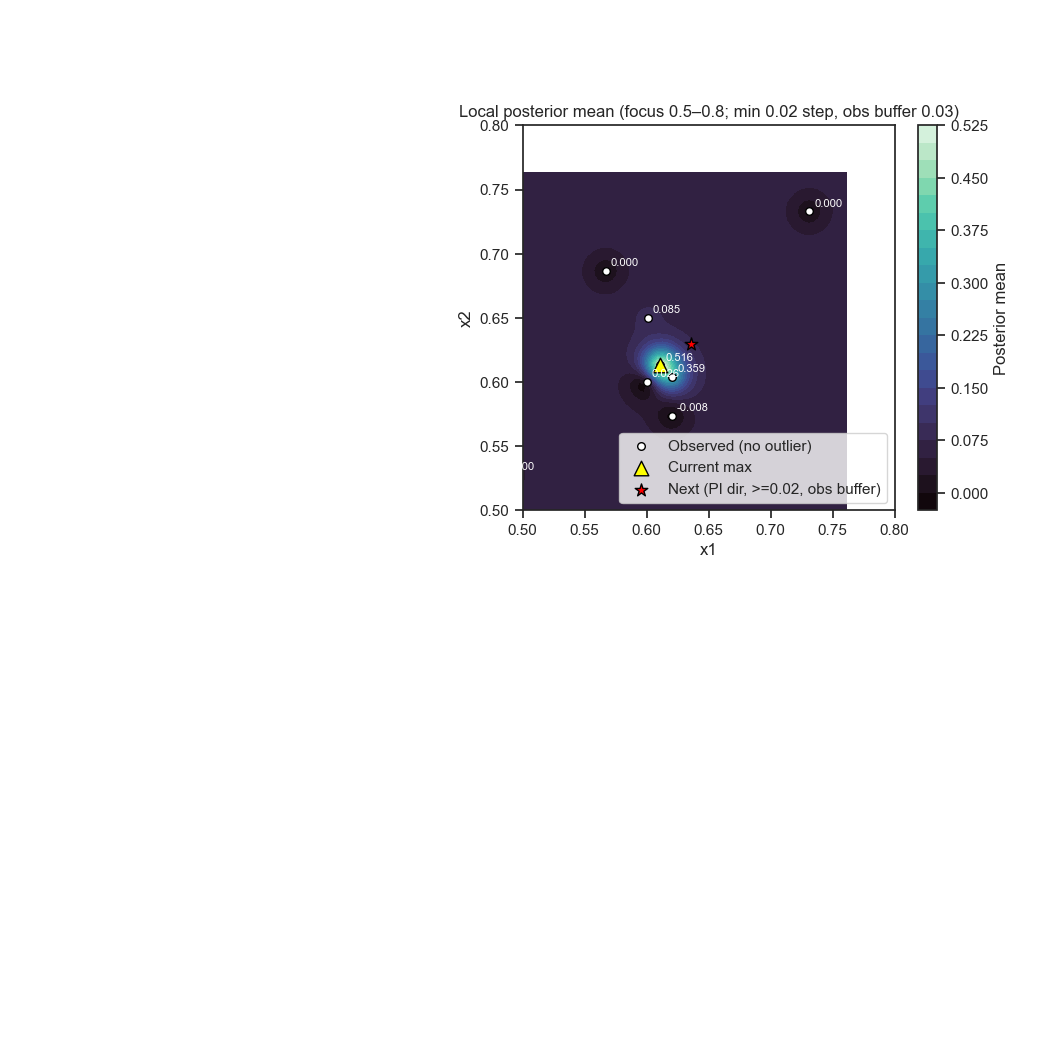

In [47]:
from scipy.special import erf
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel, Matern, WhiteKernel

df_ei = df.drop(index=4).copy()
X_train = df_ei[["x1", "x2"]].values
y_train = df_ei["y"].values
best_ei = df_ei.loc[df_ei["y"].idxmax(), ["x1", "x2"]]

# Train a GP surrogate (no radial feature) with a smoother kernel and shorter length scales
kernel = ConstantKernel(1.0, (1e-2, 10.0)) * Matern(length_scale=[0.2, 0.2], length_scale_bounds=(1e-2, 1.5), nu=2.5)
gp = GaussianProcessRegressor(kernel=kernel, normalize_y=True, n_restarts_optimizer=15, random_state=42)
gp.fit(X_train, y_train)

# Evaluate a dense grid of candidates in a local window around the best point
local_r = 0.15
x1_min, x1_max = max(best_ei.x1 - local_r, 0.0), min(best_ei.x1 + local_r, 1.0)
x2_min, x2_max = max(best_ei.x2 - local_r, 0.0), min(best_ei.x2 + local_r, 1.0)
grid_x1 = np.linspace(x1_min, x1_max, 80)
grid_x2 = np.linspace(x2_min, x2_max, 80)
mesh = np.array(np.meshgrid(grid_x1, grid_x2)).reshape(2, -1).T
mu, sigma = gp.predict(mesh, return_std=True)
y_best = y_train.max()
xi = 0.02  # small xi to stay exploitative locally

# Posterior mean gain (no EI weighting)

mu_gain = mu - y_best  # expected mean improvement over incumbent

candidate_df = pd.DataFrame(mesh, columns=["x1", "x2"])
candidate_df["mu"] = mu
candidate_df["sigma"] = sigma
candidate_df["mu_gain"] = mu_gain

# Compute distance to best; enforce a minimum 0.002 move from the current max along the BO/PI line
candidate_df["dist_to_best"] = np.linalg.norm(candidate_df[["x1", "x2"]].values - best_ei.values, axis=1)
# Distance to any observed point (avoid clustering on any prior sample)
obs_points = df_ei[["x1", "x2"]].values
candidate_df["dist_to_obs"] = np.linalg.norm(candidate_df[["x1", "x2"]].values[:, None, :] - obs_points[None, :, :], axis=2).min(axis=1)

# Enforce a modest exploration buffer from all observed points (>=0.03)
min_obs_buffer = 0.03
candidate_df_feasible = candidate_df[candidate_df["dist_to_obs"] >= min_obs_buffer].reset_index(drop=True)
if candidate_df_feasible.empty:
    candidate_df_feasible = candidate_df.copy().reset_index(drop=True)

next_point = candidate_df_feasible.loc[candidate_df_feasible["mu_gain"].idxmax()]

vec = np.array([next_point.x1 - best_ei.x1, next_point.x2 - best_ei.x2], dtype=float)
dist = np.linalg.norm(vec)
min_step = 0.002
if dist < 1e-9:
    vec = np.array([1.0, 0.0], dtype=float)
    dist = np.linalg.norm(vec)
if dist < min_step:
    vec_unit = vec / dist
    adjusted = np.clip(best_ei[["x1", "x2"]].values + vec_unit * min_step, 0, 1)
    next_point = next_point.copy()
    next_point.x1, next_point.x2 = adjusted
    next_point.note = "Adjusted to >=0.002 from max"

display(candidate_df_feasible.nlargest(5, "mu_gain"))
best_fmt = f"{best_ei.x1:.6f}-{best_ei.x2:.6f}"
next_fmt = f"{next_point.x1:.6f}-{next_point.x2:.6f}"
print(f"Current best: {best_fmt}")
print(f"Suggested next query (PI dir, min 0.002 step, obs buffer 0.03): {next_fmt}")
print(f"Posterior mean: {next_point.mu:.4f}, gain vs best: {next_point.mu_gain:.4f}, std: {next_point.sigma:.4f}")

# Visualise posterior mean surface with current observations and recommended point
mu_grid = candidate_df["mu"].values.reshape(len(grid_x2), len(grid_x1))
plt.figure(figsize=(6, 5))
contour = plt.contourf(grid_x1, grid_x2, mu_grid, levels=20, cmap="mako")
plt.colorbar(contour, label="Posterior mean")
plt.scatter(df_ei["x1"], df_ei["x2"], c="white", s=30, edgecolor="black", label="Observed (no outlier)")

# Annotate observed y values
for _, row in df_ei.iterrows():
    plt.text(row["x1"] + 0.004, row["x2"] + 0.004, f"{row['y']:.3f}", fontsize=8, color="white")

# Highlight current max and next
plt.scatter(best_ei.x1, best_ei.x2, c="yellow", s=110, marker="^", edgecolor="black", label="Current max")
plt.scatter(next_point.x1, next_point.x2, c="red", s=90, marker="*", edgecolor="black", label="Next (PI dir, >=0.002, obs buffer)")

# Focused view 0.5–0.8
plt.xlim(0.5, 0.8)
plt.ylim(0.5, 0.8)
plt.title("Local posterior mean (focus 0.5–0.8; min 0.002 step, obs buffer 0.03)")
plt.xlabel("x1")
plt.ylabel("x2")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


## Final shortlist of candidate moves
The table below lists the top local PI points (with the ≥0.002 step + 0.03 obs buffer guardrails). Pick the point you prefer from the PI shortlist.


In [48]:
if "candidate_df_feasible" in globals():
    top_mean = candidate_df_feasible.nlargest(3, "mu_gain").copy()
    top_mean["id"] = [f"pi_top_{i+1}" for i in range(len(top_mean))]
    top_mean["note"] = "Local PI/mean (min 0.002 step, obs buffer 0.03)"
    top_mean["source"] = "local_mean"
    top_mean = top_mean[["source", "id", "x1", "x2", "note", "mu_gain", "mu", "sigma"]]
    display(top_mean)
else:
    print("Run the PI cell first to populate options.")



,source,id,x1,x2,note,mu_gain,mu,sigma
2992,local_mean,pi_top_1,0.635684,0.630089,"Local PI/mean (min 0.02 step, obs buffer 0.03)",-0.434829,0.081002,0.135665
3057,local_mean,pi_top_2,0.635684,0.633886,"Local PI/mean (min 0.02 step, obs buffer 0.03)",-0.441696,0.074136,0.135729
2993,local_mean,pi_top_3,0.639481,0.630089,"Local PI/mean (min 0.02 step, obs buffer 0.03)",-0.442134,0.073697,0.135731


## Summary and recommended point
- **Current best:** `0.611000-0.613000` (≈0.51583).
- **Recommended next point (format: 6 decimals, dash-separated):** `0.635684-0.630089`
- Rationale: BO/PI has delivered consecutive new maxima; the 0.002 guardrail plus 0.03 buffer keeps us moving in the proven direction without clustering on incumbents.
